# GraphRAG Evaluation

This notebook evaluates the GraphRAG pipeline output across three independent components:
1. **Graph retrieval reliability** — entity-level Precision, Recall, F1
2. **Graph generation quality** — LLM-as-a-Judge (reference-guided, multi-agent)
3. **Evaluation cost** — token usage and USD cost per judge

Only **Cell 1 (Configuration)** needs to be edited. All other cells run automatically.

## ⚙️ Cell 1 — Configuration
> Edit only this cell before running the notebook.

In [4]:
import os
# ══════════════════════════════════════════════════════════════════
#  CONFIGURATION — edit only this section
# ══════════════════════════════════════════════════════════════════

# ── Input / Output paths ─────────────────────────────────────────
GRAPHRAG_OUTPUT_PATH = r"graphrag\data\output\graphrag_results_20260522_171129.xlsx"
GRAPH_PATH            = "LOTO-RO_grounded_KG.xlsx"                # source KG Excel file
OUTPUT_DIR           = "Evaluationresults/"                                           # output directory for all results

# ── API keys ─────────────────────────────────────────────────────
# Recommendation: set as environment variables (OPENAI_API_KEY, GOOGLE_API_KEY)
# and leave these as empty strings.
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")    # set via environment variable, do not hardcode
GEMINI_API_KEY = os.environ.get("GOOGLE_API_KEY", "")  # set via environment variable, do not hardcode

# ── Judge models ─────────────────────────────────────────────────
GPT_MODEL    = "gpt-5.4"      # OpenAI model for judge (Step C evaluator)
GEMINI_MODEL = "gemini-3.5-flash"  # Google model for judge (Step C evaluator)

# ── Judge settings ───────────────────────────────────────────────
TEMPERATURE  = 0.2    # low temperature for reproducible scores
MAX_TOKENS   = 1200   # output token budget per judge call
MAX_RETRIES  = 3      # retry attempts on API or JSON errors
DELAY        = 1.5    # seconds between calls (rate limit safety)

# ── Pricing — USD per 1M tokens (update as needed) ───────────────
# https://openai.com/pricing  |  https://ai.google.dev/pricing
PRICING = {
    "openai": {"i": 2.50,  "o": 10.00},   # gpt-5.4
    "gemini": {"i": 0.075, "o": 0.30},    # gemini-3.5-flash
}

# ══════════════════════════════════════════════════════════════════
print("Configuration loaded ✓")
print(f"  GraphRAG output : {GRAPHRAG_OUTPUT_PATH}")
print(f"  KG source       : {GRAPH_PATH}")
print(f"  Output dir      : {OUTPUT_DIR}")
print(f"  GPT model       : {GPT_MODEL}")
print(f"  Gemini model    : {GEMINI_MODEL}")
print(f"  Temperature     : {TEMPERATURE}  |  Max tokens: {MAX_TOKENS}")


Configuration loaded ✓
  GraphRAG output : graphrag\data\output\graphrag_results_20260522_171129.xlsx
  KG source       : LOTO-RO_grounded_KG.xlsx
  Output dir      : Evaluationresults/
  GPT model       : gpt-5.4
  Gemini model    : gemini-3.5-flash
  Temperature     : 0.2  |  Max tokens: 1200


---
## 📐 Section 2 — Graph Retrieval Reliability: Precision, Recall, F1

Entity-level set-based matching between retrieved entity titles (`Cited_Entities_IDs` → resolved to titles) and expert-annotated gold reference (`Gold_Entity_Titles`).

| Metric | Definition |
|--------|------------|
| **Precision** | Of all retrieved entities, what fraction is relevant? |
| **Recall** | Of all relevant entities, what fraction was retrieved? |
| **F1** | Harmonic mean of Precision and Recall |

Entity IDs are resolved to human-readable titles via the KG source file before comparison. Titles are lowercased for case-insensitive matching.

Libraries loaded ✓
Metric functions defined ✓
Loaded: graphrag_results_20260522_171129.xlsx  →  180 rows, 12 columns
Categories: ['Classification', 'Comparison', 'Information Retrieval', 'Reasoning', 'Recommendation', 'Summarization']
✓ All entity IDs resolved correctly.
Metrics computed on 180 rows ✓
  GLOBAL RESULTS


,Search_Type,P_mean,R_mean,F1_mean,N
0,Local,0.6305,0.4366,0.4499,180



  RESULTS PER CATEGORY


,Search_Type,Category,P_mean,R_mean,F1_mean,N
0,Local,Classification,0.6507,0.7835,0.6601,30
1,Local,Comparison,0.7347,0.4388,0.4910,30
2,Local,Information Retrieval,0.6330,0.3723,0.3971,30
3,Local,Reasoning,0.5372,0.5468,0.5342,30
4,Local,Recommendation,0.5569,0.2946,0.3555,30
5,Local,Summarization,0.6706,0.1838,0.2617,30


Saved: Evaluationresults\eval_retrieval_20260522_213538.xlsx ✓


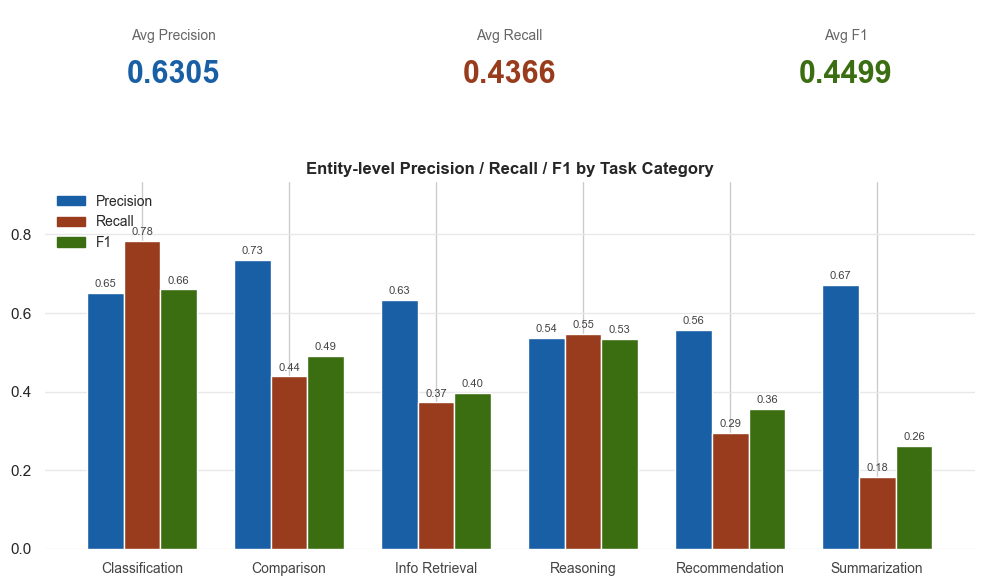

Chart saved: Evaluationresults/retrieval_chart.png ✓


In [ ]:
# ── 2.1 Imports and metric functions ─────────────────────────────────────────
import os
import re
import json
import time
import warnings
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter
from openpyxl.formatting.rule import ColorScaleRule

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print("Libraries loaded ✓")


def parse_set(cell) -> set:
    """Converts a CSV cell to a normalised set of lowercase tokens."""
    s = str(cell).strip() if cell is not None else ""
    if s.lower() in ("", "nan", "none", "all incidents"):
        return set()
    return {x.strip().lower() for x in s.split(",") if x.strip()}


def prf(retrieved: set, relevant: set) -> tuple:
    """Returns (precision, recall, F1) given retrieved and relevant sets."""
    if not retrieved and not relevant:
        return 1.0, 1.0, 1.0
    if not retrieved:
        return 0.0, 0.0, 0.0
    if not relevant:
        return 0.0, 1.0, 0.0
    tp = len(retrieved & relevant)
    p  = tp / len(retrieved)
    r  = tp / len(relevant)
    f1 = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
    return round(p, 4), round(r, 4), round(f1, 4)


def evaluate_row(row) -> pd.Series:
    retrieved = parse_set(row["Extracted_Entity_Titles"])
    relevant  = parse_set(row["Gold_Entity_Titles"])
    p, r, f1  = prf(retrieved, relevant)
    correct   = retrieved & relevant
    return pd.Series({
        "Precision": p,
        "Recall":    r,
        "F1":        f1,
        "TP":        len(correct),
        "FP":        len(retrieved - relevant),
        "FN":        len(relevant  - retrieved),
        "Correct":   ", ".join(sorted(correct))              or "—",
        "Missing":   ", ".join(sorted(relevant - retrieved)) or "—",
        "Extra":     ", ".join(sorted(retrieved - relevant)) or "—",
    })


print("Metric functions defined ✓")

# ── 2.2 Load data and resolve entity IDs → titles ────────────────────────────

input_path = Path(GRAPHRAG_OUTPUT_PATH)
df_pr = pd.read_excel(input_path)

# Load KG entity index for ID → title resolution
df_ent = pd.read_excel(GRAPH_PATH, sheet_name="entità")
id_to_title: dict[str, str] = {
    str(k).strip(): str(v)
    for k, v in zip(df_ent["id"], df_ent["title"])
    if pd.notna(k) and pd.notna(v)
}


def ids_to_titles(cell) -> str:
    """Resolves a comma-separated list of entity IDs to human-readable titles."""
    s = str(cell).strip() if cell is not None else ""
    if s.lower() in ("", "nan", "none"):
        return ""
    titles = []
    for raw_id in s.split(","):
        rid   = raw_id.strip()
        title = id_to_title.get(rid)
        titles.append(title if title else f"[UNKNOWN:{rid}]")
    return ", ".join(titles)


df_pr["Extracted_Entity_Titles"] = df_pr["Cited_Entities_IDs"].apply(ids_to_titles)

print(f"Loaded: {input_path.name}  →  {len(df_pr)} rows, {len(df_pr.columns)} columns")
print(f"Categories: {df_pr['Category'].unique().tolist()}")

# Warn on unresolved IDs
unknown_mask = df_pr["Extracted_Entity_Titles"].str.contains(r"\[UNKNOWN:", na=False)
if unknown_mask.any():
    print(f"\n⚠️  {unknown_mask.sum()} rows contain unresolved entity IDs:")
    print(df_pr.loc[unknown_mask, ["Task_ID", "Cited_Entities_IDs", "Extracted_Entity_Titles"]].to_string())
else:
    print("✓ All entity IDs resolved correctly.")

# ── 2.3 Compute metrics row by row ───────────────────────────────────────────

metrics = df_pr.apply(evaluate_row, axis=1)

detail = pd.concat([
    df_pr[["Task_ID", "Variant", "Category", "Search_Type",
           "query", "Gold_Answer", "GraphRAG_Answer",
           "Extracted_Entity_Titles", "Gold_Entity_Titles"]].reset_index(drop=True),
    metrics.reset_index(drop=True),
], axis=1)

print(f"Metrics computed on {len(detail)} rows ✓")
detail[["Task_ID", "Variant", "Category", "Precision", "Recall", "F1", "TP", "FP", "FN"]].head(8)

# ── 2.4 Aggregation: global and per-category ─────────────────────────────────

AGG = {
    "P_mean":  ("Precision", "mean"),
    "R_mean":  ("Recall",    "mean"),
    "F1_mean": ("F1",        "mean"),
    "N":       ("F1",        "count"),
}

global_df  = detail.groupby("Search_Type", as_index=False).agg(**AGG).round(4)
summary_df = detail.groupby(["Search_Type", "Category"], as_index=False).agg(**AGG).round(4)

print("=" * 55)
print("  GLOBAL RESULTS")
print("=" * 55)
display(global_df)

print("\n" + "=" * 55)
print("  RESULTS PER CATEGORY")
print("=" * 55)
display(summary_df)

# ── 2.5 Save to Excel (styled) and plot ──────────────────────────────────────

HEADER_COLORS = {"global": "1F3864", "summary": "2E75B6", "detail": "375623"}
COL_WIDTHS = {
    "Task_ID": 9, "Variant": 8, "Category": 20, "Search_Type": 12,
    "query": 45, "Gold_Answer": 50, "GraphRAG_Answer": 55,
    "Extracted_Entity_Titles": 45, "Gold_Entity_Titles": 45,
    "Precision": 11, "Recall": 10, "F1": 10,
    "P_mean": 11, "R_mean": 10, "F1_mean": 10,
    "TP": 6, "FP": 6, "FN": 6, "N": 6,
    "Correct": 40, "Missing": 40, "Extra": 40,
}
METRIC_COLS = {"Precision", "Recall", "F1", "P_mean", "R_mean", "F1_mean"}


def _style_sheet(ws, df_len: int, header_color: str):
    hfill = PatternFill("solid", fgColor=header_color)
    hfont = Font(bold=True, color="FFFFFF", size=10)
    for cell in ws[1]:
        cell.font      = hfont
        cell.fill      = hfill
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    ws.row_dimensions[1].height = 28
    metric_cols_idx = []
    for ci in range(1, ws.max_column + 1):
        h  = ws.cell(1, ci).value or ""
        cl = get_column_letter(ci)
        ws.column_dimensions[cl].width = COL_WIDTHS.get(h, 18)
        if h in METRIC_COLS:
            metric_cols_idx.append(ci)
    for row in ws.iter_rows(min_row=2):
        for cell in row:
            cell.alignment = Alignment(wrap_text=True, vertical="top")
    for r in range(2, df_len + 2):
        ws.row_dimensions[r].height = 55
    last = ws.max_row
    for ci in metric_cols_idx:
        cl = get_column_letter(ci)
        ws.conditional_formatting.add(
            f"{cl}2:{cl}{last}",
            ColorScaleRule(
                start_type="num", start_value=0,   start_color="FF0000",
                mid_type="num",   mid_value=0.5,   mid_color="FFFF00",
                end_type="num",   end_value=1,      end_color="00B050",
            ),
        )
    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions


ts       = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = Path(OUTPUT_DIR) / f"eval_retrieval_{ts}.xlsx"
sheets   = [("global", "Global", global_df), ("summary", "By Category", summary_df), ("detail", "Detail", detail)]

with pd.ExcelWriter(str(out_path), engine="openpyxl") as w:
    for key, sheet_name, df_out in sheets:
        df_out.to_excel(w, index=False, sheet_name=sheet_name)
        _style_sheet(w.sheets[sheet_name], len(df_out), HEADER_COLORS[key])

print(f"Saved: {out_path} ✓")

# ── Bar chart: P / R / F1 Score per category (standalone re-plot) ─────────────

categories = summary_df["Category"]          # ← "Information Retrieval" invariato
x     = np.arange(len(categories))
width = 0.25
avg_p  = detail["Precision"].mean()
avg_r  = detail["Recall"].mean()
avg_f1 = detail["F1"].mean()

fig = plt.figure(figsize=(12, 7), facecolor="white")
gs  = fig.add_gridspec(2, 3, height_ratios=[1, 4], hspace=0.35, wspace=0.3)

for ax_c, label, value, color in [
    (fig.add_subplot(gs[0, 0]), "Avg Precision",  avg_p,  "#185FA5"),
    (fig.add_subplot(gs[0, 1]), "Avg Recall",     avg_r,  "#993C1D"),
    (fig.add_subplot(gs[0, 2]), "Avg F1 Score",   avg_f1, "#3B6D11"),  # ← F1 Score
]:
    ax_c.set_facecolor("#f5f5f5"); ax_c.set_xlim(0, 1); ax_c.set_ylim(0, 1); ax_c.axis("off")
    ax_c.text(0.5, 0.72, label, ha="center", va="center", fontsize=10, color="#666", transform=ax_c.transAxes)
    ax_c.text(0.5, 0.30, f"{value:.4f}", ha="center", va="center", fontsize=22, fontweight="bold", color=color, transform=ax_c.transAxes)

ax = fig.add_subplot(gs[1, :])
ax.set_facecolor("white")
b1 = ax.bar(x - width, summary_df["P_mean"],  width, color="#185FA5", label="Precision", zorder=3)
b2 = ax.bar(x,         summary_df["R_mean"],  width, color="#993C1D", label="Recall",    zorder=3)
b3 = ax.bar(x + width, summary_df["F1_mean"], width, color="#3B6D11", label="F1 Score",  zorder=3)  # ← F1 Score
for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.2f}",
                ha="center", va="bottom", fontsize=8, color="#444")

ax.set_xticks(x); ax.set_xticklabels(categories, fontsize=10, color="#444")
ax.set_ylim(0, max(summary_df[["P_mean", "R_mean", "F1_mean"]].max()) + 0.15)
ax.yaxis.grid(True, color="#e8e8e8", zorder=0); ax.set_axisbelow(True)
for spine in ax.spines.values(): spine.set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.legend(handles=[
    mpatches.Patch(color="#185FA5", label="Precision"),
    mpatches.Patch(color="#993C1D", label="Recall"),
    mpatches.Patch(color="#3B6D11", label="F1 Score"),   # ← F1 Score
], frameon=False, fontsize=10, loc="upper left")
ax.set_title("Entity-level Precision / Recall / F1 Score by Task Category",
             fontweight="bold", fontsize=12)                              # ← F1 Score

chart_path = f"{OUTPUT_DIR}retrieval_chart_v2.png"   # nome diverso per non sovrascrivere
plt.savefig(chart_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Chart saved: {chart_path} ✓")

---
## 🤖 Section 3 — Graph Generation Quality: LLM-as-a-Judge

Reference-guided grading on a 1–5 Likert scale across six evaluation criteria, using a multi-agent strategy (two independent judges from distinct provider families) to mitigate single-judge variance.

| Criterion | What it measures |
|-----------|------------------|
| **Faithfulness** | Every claim grounded in the retrieved subgraph — penalises hallucinations |
| **Accuracy** | Factual alignment with the expert-validated gold answer |
| **Comprehensiveness** | Coverage of required procedural, causal, and relational aspects |
| **Relevance & Conciseness** | Answer focused on the query without off-topic padding |
| **Clarity & Readability** | Logical structure and readability |
| **Overall Coherence** | Internal consistency, free of contradictions |
| **Empowerment** | Decision-support utility for a safety professional |

> **Context Confidence** is evaluated independently to distinguish retrieval failures from generation failures.

A response is considered **acceptable** at score ≥ 4.

In [6]:
# ── 3.1 Setup: config dataclass, score fields, KG loading ────────────────────

@dataclass
class JudgeConfig:
    responses_path: str   = GRAPHRAG_OUTPUT_PATH
    graph_path:     str   = GRAPH_PATH
    output_dir:     str   = OUTPUT_DIR
    openai_api_key: str   = field(default_factory=lambda: os.getenv("OPENAI_API_KEY", OPENAI_API_KEY))
    gemini_api_key: str   = field(default_factory=lambda: os.getenv("GEMINI_API_KEY", GEMINI_API_KEY))
    gpt_model:      str   = GPT_MODEL
    gemini_model:   str   = GEMINI_MODEL
    temperature:    float = TEMPERATURE
    max_tokens:     int   = MAX_TOKENS
    max_retries:    int   = MAX_RETRIES
    delay:          float = DELAY
    col_answer:     str   = "GraphRAG_Answer"
    col_gold:       str   = "Gold_Answer"
    col_query:      str   = "query"


config = JudgeConfig()

SCORE_FIELDS = [
    "faithfulness_to_source",
    "factual_accuracy",
    "completeness",
    "relevance_and_conciseness",
    "clarity_and_readability",
    "overall_coherence",
    "empowerment",
]
LABELS = ["Faithfulness", "Accuracy", "Completeness", "Relevance", "Clarity", "Coherence", "Empowerment"]
SC     = [f"s_{f}" for f in SCORE_FIELDS]
JUDGE_LABELS = {"openai": "GPT", "gemini": "Gemini"}

# Verify keys
print(f"Config OK — models: {config.gpt_model} | {config.gemini_model}")
print(f"OpenAI key set: {bool(config.openai_api_key) and config.openai_api_key not in ('', None)}")
print(f"Gemini key set: {bool(config.gemini_api_key) and config.gemini_api_key not in ('', None)}")

# Load responses
df_raw = pd.read_excel(config.responses_path)
print(f"\nColumns: {df_raw.columns.tolist()}")
print(f"Total rows: {len(df_raw)}")

df = df_raw.dropna(subset=[config.col_answer]).copy()
df = df[df[config.col_answer].astype(str).str.strip() != ""]

task_id_str      = df["Task_ID"].astype(str)
df["task_group"] = task_id_str.apply(lambda x: int(x.split(".")[0]))
decimal_part     = task_id_str.apply(lambda x: x.split(".")[-1] if "." in x else "0")
df["variant_type"] = decimal_part.map({"0": "Original", "1": "Synonym", "2": "Synonym", "3": "PE"})
df["has_R"]        = df["Variant"].isin(["R1", "R2", "R3"])
df["Gold_Answer"]  = df[config.col_gold].fillna("")
print(f"Final dataset: {len(df)} records")

# Load KG for context building
tu_df = pd.read_excel(config.graph_path, sheet_name="testi")
en_df = pd.read_excel(config.graph_path, sheet_name="entità")

source_map: dict[str, str] = {
    str(k).strip(): str(v)
    for k, v in zip(tu_df["id"], tu_df["text"].fillna(""))
    if pd.notna(k)
}
entity_map: dict[str, tuple] = {
    str(row["id"]).strip(): (str(row["title"]), str(row["type"]), str(row["description"]))
    for _, row in en_df.iterrows()
    if pd.notna(row["id"])
}
id_to_title_judge: dict[str, str] = {
    str(k).strip(): str(v)
    for k, v in zip(en_df["id"], en_df["title"])
    if pd.notna(k) and pd.notna(v)
}
print(f"Narratives: {len(source_map)} | Entities: {len(entity_map)}")

def parse_ids(id_string) -> list[str]:
    if pd.isna(id_string) or str(id_string).strip() in ("", "—", "nan"):
        return []
    return [tok for tok in re.split(r"[\s,]+", str(id_string).strip()) if tok]

def build_context(row) -> str:
    narratives = []
    for sid in parse_ids(row.get("Cited_Source_IDs", "")):
        text = source_map.get(sid, "")
        if text:
            narratives.append(f"[Incident Narrative {sid}]\n{text}")
    entity_blocks = []
    for eid in parse_ids(row.get("Cited_Entities_IDs", "")):
        info = entity_map.get(eid)
        if info:
            title, etype, desc = info
            entity_blocks.append(f"[{etype}] {title} (ID {eid})\n{desc}")
    return (
        "=== INCIDENT NARRATIVES ===\n\n" +
        ("\n\n".join(narratives) if narratives else "[No narratives retrieved]") +
        "\n\n=== ENTITY DEFINITIONS (from LOTO KG) ===\n\n" +
        ("\n\n".join(entity_blocks) if entity_blocks else "[No entities retrieved]")
    )

df["Extracted_Entity_Titles_judge"] = df["Cited_Entities_IDs"].apply(
    lambda c: ", ".join(id_to_title_judge.get(i.strip(), f"[UNKNOWN:{i.strip()}]") for i in re.split(r"[\s,]+", str(c).strip()) if i.strip())
)
unknown_j = df["Extracted_Entity_Titles_judge"].str.contains(r"\[UNKNOWN:", na=False)
if unknown_j.any():
    print(f"⚠️  {unknown_j.sum()} rows with unresolved IDs")
else:
    print("✓ All entity IDs resolved.")
sample_ctx = build_context(df.iloc[0])
print(f"Context sample: {len(sample_ctx)} chars")

# ── 3.2 Evaluation prompts ────────────────────────────────────────────────────

SYSTEM_PROMPT = """
### Role and Objective

You are an expert evaluator of the quality of answers generated by a GraphRAG question-answering system
applied to Lockout/Tagout (LOTO) industrial incident reports.
Your sole task is to analyze the information provided and respond with a structured JSON evaluation.
You must not respond in any other way. Respond ONLY with valid JSON — no preamble, no markdown fences.

### Instructions

You must perform a detailed evaluation for each of the seven criteria listed below.
For each criterion, provide:
1. A numerical score (from 1 to 5) within the 'scores' object.
2. A brief textual justification within the 'justifications' object.

### Evaluation Criteria

1. Faithfulness to Source ('faithfulness_to_source'):
Assign a score from 1 to 5. Are the claims in the GraphRAG Answer generally supported by the
Retrieved Context (incident narratives or entity definitions)?
Penalise only clear fabrications or statements that directly contradict the context.
Justification: Note any unsupported claims or confirm grounding.

2. Factual Accuracy ('factual_accuracy'):
Assign a score from 1 to 5. Is the factual content of the GraphRAG Answer broadly consistent
with the Gold Answer on the main points?
Justification: Note any significant error or confirm correctness.

3. Completeness ('completeness'):
Assign a score from 1 to 5. Does the GraphRAG Answer address the main elements of the question
as covered by the Gold Answer? Minor omissions are acceptable.
Justification: Note any significant gap or confirm adequate coverage.

4. Relevance and Conciseness ('relevance_and_conciseness'):
Assign a score from 1 to 5. Is the answer focused on the question without excessive padding
or off-topic content?
Justification: Identify clearly irrelevant passages or confirm focus.

5. Clarity and Readability ('clarity_and_readability'):
Assign a score from 1 to 5. Is the answer understandable and reasonably well-structured?
Justification: Note any clarity issues or confirm readability.

6. Overall Coherence ('overall_coherence'):
Assign a score from 1 to 5. Is the answer internally consistent and free of major contradictions?
Justification: Identify contradictions or confirm coherence.

7. Empowerment ('empowerment'):
Assign a score from 1 to 5. Does the answer provide useful information for a safety professional
working on LOTO incident prevention?
Justification: Describe useful elements present or explain their absence.

Additionally, evaluate:
- context_confidence: {{ "score": <1-5>, "note": "<brief note>" }}
  How adequate is the retrieved context for answering this question?
  (1 = completely inadequate, 5 = fully sufficient)
  This metric is independent and used to distinguish retrieval failures from generation failures.

### Response Format

Respond ONLY with the following JSON structure:
{{
  "scores": {{
    "faithfulness_to_source": <int 1-5>,
    "factual_accuracy": <int 1-5>,
    "completeness": <int 1-5>,
    "relevance_and_conciseness": <int 1-5>,
    "clarity_and_readability": <int 1-5>,
    "overall_coherence": <int 1-5>,
    "empowerment": <int 1-5>
  }},
  "justifications": {{
    "faithfulness_to_source": "<text>",
    "factual_accuracy": "<text>",
    "completeness": "<text>",
    "relevance_and_conciseness": "<text>",
    "clarity_and_readability": "<text>",
    "overall_coherence": "<text>",
    "empowerment": "<text>"
  }},
  "context_confidence": {{ "score": <int 1-5>, "note": "<text>" }}
}}
"""

USER_PROMPT = """
### Question
{question}

### Retrieved Context
{retrieved_context}

### GraphRAG Answer (to evaluate)
{graphrag_answer}

### Gold Answer (reference)
{gold_answer}

Evaluate the GraphRAG Answer against all seven criteria and respond with the JSON only.
"""

print("Prompts defined ✓")

# ── 3.3 LLMJudge class and validation ────────────────────────────────────────

class LLMJudge:
    def __init__(self, provider: str, cfg: JudgeConfig):
        self.provider = provider
        self.cfg = cfg
        self.tok_in = self.tok_out = self.n = 0

        if provider == "openai":
            import openai
            self.client = openai.OpenAI(api_key=cfg.openai_api_key)
            self.model  = cfg.gpt_model
        elif provider == "gemini":
            from google import genai
            self.client = genai.Client(api_key=cfg.gemini_api_key)
            self.model  = cfg.gemini_model
        else:
            raise ValueError(f"Unknown provider: {provider}")

    def _parse(self, txt: str) -> dict:
        c = re.sub(r"^```(?:json)?\s*", "", txt.strip())
        c = re.sub(r"\s*```$", "", c)
        return json.loads(c)

    def call(self, sys_p: str, usr_p: str) -> dict:
        for att in range(self.cfg.max_retries):
            try:
                t0 = time.time()
                if self.provider == "openai":
                    r = self.client.chat.completions.create(
                        model                  = self.model,
                        max_completion_tokens  = self.cfg.max_tokens,
                        temperature            = self.cfg.temperature,
                        messages               = [{"role": "system", "content": sys_p},
                                                {"role": "user",   "content": usr_p}],
                    )
                    txt = r.choices[0].message.content
                    u   = {"i": r.usage.prompt_tokens, "o": r.usage.completion_tokens}
                else:  # gemini
                    from google.genai import types
                    gen_cfg_kwargs = dict(
                        system_instruction = sys_p,
                        temperature        = self.cfg.temperature,
                        max_output_tokens  = self.cfg.max_tokens,
                    )
                    try:
                        gen_cfg_kwargs["thinking_config"] = types.ThinkingConfig(thinking_budget=0)
                    except AttributeError:
                        pass
                    r   = self.client.models.generate_content(
                        model   = self.model,
                        contents= usr_p,
                        config  = types.GenerateContentConfig(**gen_cfg_kwargs),
                    )
                    txt = r.text
                    try:
                        u = {"i": r.usage_metadata.prompt_token_count,
                             "o": r.usage_metadata.candidates_token_count}
                    except Exception:
                        u = {"i": 0, "o": 0}

                self.tok_in  += u["i"]
                self.tok_out += u["o"]
                self.n       += 1
                parsed = self._parse(txt)
                parsed["_u"] = u
                parsed["_t"] = round(time.time() - t0, 2)
                time.sleep(self.cfg.delay)
                return parsed

            except json.JSONDecodeError:
                if att == self.cfg.max_retries - 1:
                    return {"error": "JSON parse", "raw": txt[:400]}
                time.sleep(2)
            except Exception as e:
                if att == self.cfg.max_retries - 1:
                    return {"error": str(e)}
                time.sleep(2 * (att + 1))


def valid(r: dict) -> bool:
    if not r or "error" in r or "scores" not in r:
        return False
    return all(
        isinstance(r["scores"].get(f), (int, float)) and 1 <= r["scores"][f] <= 5
        for f in SCORE_FIELDS
    )

print("LLMJudge class defined ✓")

# ── 3.4 Evaluate function ─────────────────────────────────────────────────────

def evaluate(judge: LLMJudge, data: pd.DataFrame, max_rows=None, desc="Eval") -> pd.DataFrame:
    out = []
    sub = data.head(max_rows) if max_rows else data

    for _, row in tqdm(sub.iterrows(), total=len(sub), desc=f"{desc} [{judge.provider}]"):
        question = row.get("query", "")
        ans      = str(row.get(judge.cfg.col_answer, ""))
        gold     = str(row.get("Gold_Answer", ""))
        usr_p    = USER_PROMPT.format(
            question          = question,
            retrieved_context = build_context(row),
            graphrag_answer   = ans,
            gold_answer       = gold,
        )
        r = judge.call(SYSTEM_PROMPT, usr_p)

        base = {
            "Task_ID":      row["Task_ID"],
            "Variant":      row.get("Variant"),
            "Category":     row.get("Category", ""),
            "judge":        judge.provider,
            "has_R":        row.get("has_R", False),
            "task_group":   row.get("task_group", 0),
            "search_type":  row.get("Search_Type", "?"),
            "variant_type": row.get("variant_type", "Original"),
        }

        if valid(r):
            for f in SCORE_FIELDS:
                base[f"s_{f}"]   = int(r["scores"][f])
                base[f"sar_{f}"] = int(r["scores"][f] >= 4)
                base[f"j_{f}"]   = r.get("justifications", {}).get(f, "")
            cc = r.get("context_confidence", {})
            base["ctx_conf"]   = cc.get("score", 0) if isinstance(cc, dict) else 0
            base["ctx_note"]   = cc.get("note",  "") if isinstance(cc, dict) else ""
            base["justif_len"] = sum(len(str(v)) for v in r.get("justifications", {}).values())
            base["tok_in"]     = r.get("_u", {}).get("i", 0)
            base["tok_out"]    = r.get("_u", {}).get("o", 0)
            base["time_s"]     = r.get("_t", 0)
            base["gold_clean"] = gold[:500]
            base["ans_clean"]  = ans[:500]
        else:
            base["error"] = r.get("error", "unknown")
            if "raw" in r:
                base["error_raw"] = r["raw"]

        out.append(base)

    return pd.DataFrame(out)

print("evaluate() function defined ✓")

# ── 3.5 Run evaluation ────────────────────────────────────────────────────────
# ⚠️  Uncomment the API test block below before the first full run.

# # API test (run once to verify connectivity before the full loop)
# def test_judge(judge: LLMJudge):
#     r = judge.call('Respond ONLY with valid JSON: {"ok": true}', "Return the JSON now.")
#     print(f"[{judge.provider}] ping: {r}")
#     row = df.iloc[0]
#     usr_p = USER_PROMPT.format(
#         question=row.get("query",""), retrieved_context=build_context(row),
#         graphrag_answer=str(row.get(config.col_answer,"")), gold_answer=str(row.get("Gold_Answer",""))
#     )
#     r2 = judge.call(SYSTEM_PROMPT, usr_p)
#     print(f"[{judge.provider}] real call valid={valid(r2)}  scores={r2.get('scores')}")
#
# test_judge(LLMJudge("openai", config))
# test_judge(LLMJudge("gemini", config))

MAX_ROWS = None   # ← None for full run; set to e.g. 10 for a test run

judge_gpt    = LLMJudge("openai", config)
judge_gemini = LLMJudge("gemini", config)

res_gpt    = evaluate(judge_gpt,    df, MAX_ROWS, "GPT")
res_gemini = evaluate(judge_gemini, df, MAX_ROWS, "Gemini")

all_res = pd.concat([res_gpt, res_gemini], ignore_index=True)
for col in SC:
    if col not in all_res.columns:
        all_res[col] = np.nan

ts       = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = f"{config.output_dir}eval_judge_{ts}.xlsx"
all_res.to_excel(out_path, index=False)
print(f"\n✓ Saved: {len(all_res)} records → {out_path}")
print(f"  GPT: {len(res_gpt)}  |  Gemini: {len(res_gemini)}")



Config OK — models: gpt-5.4 | gemini-3.5-flash
OpenAI key set: True
Gemini key set: True

Columns: ['Task_ID', 'Variant', 'Category', 'query', 'Gold_Answer', 'Gold_Entity_Titles', 'Search_Type', 'GraphRAG_Answer', 'Status', 'Cited_Source_IDs', 'Cited_Entities_IDs']
Total rows: 180
Final dataset: 180 records
Narratives: 20 | Entities: 137
⚠️  1 rows with unresolved IDs
Context sample: 20218 chars
Prompts defined ✓
LLMJudge class defined ✓
evaluate() function defined ✓


GPT [openai]:   0%|          | 0/180 [00:00<?, ?it/s]

Gemini [gemini]:   0%|          | 0/180 [00:00<?, ?it/s]


✓ Saved: 360 records → Evaluationresults/eval_judge_20260522_221944.xlsx
  GPT: 180  |  Gemini: 180


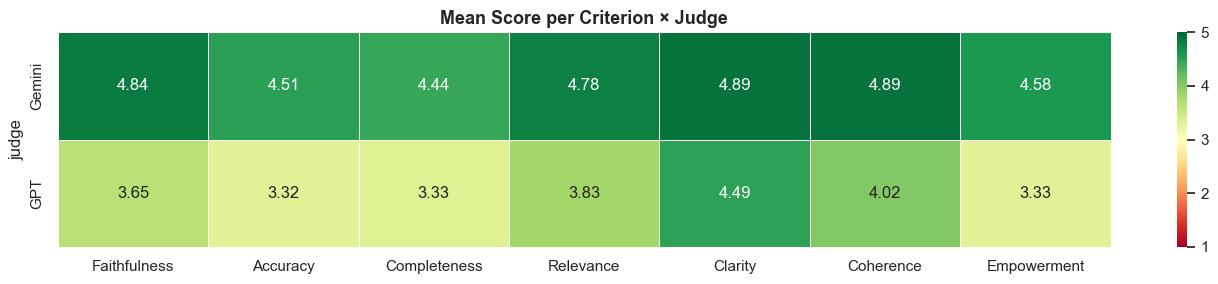

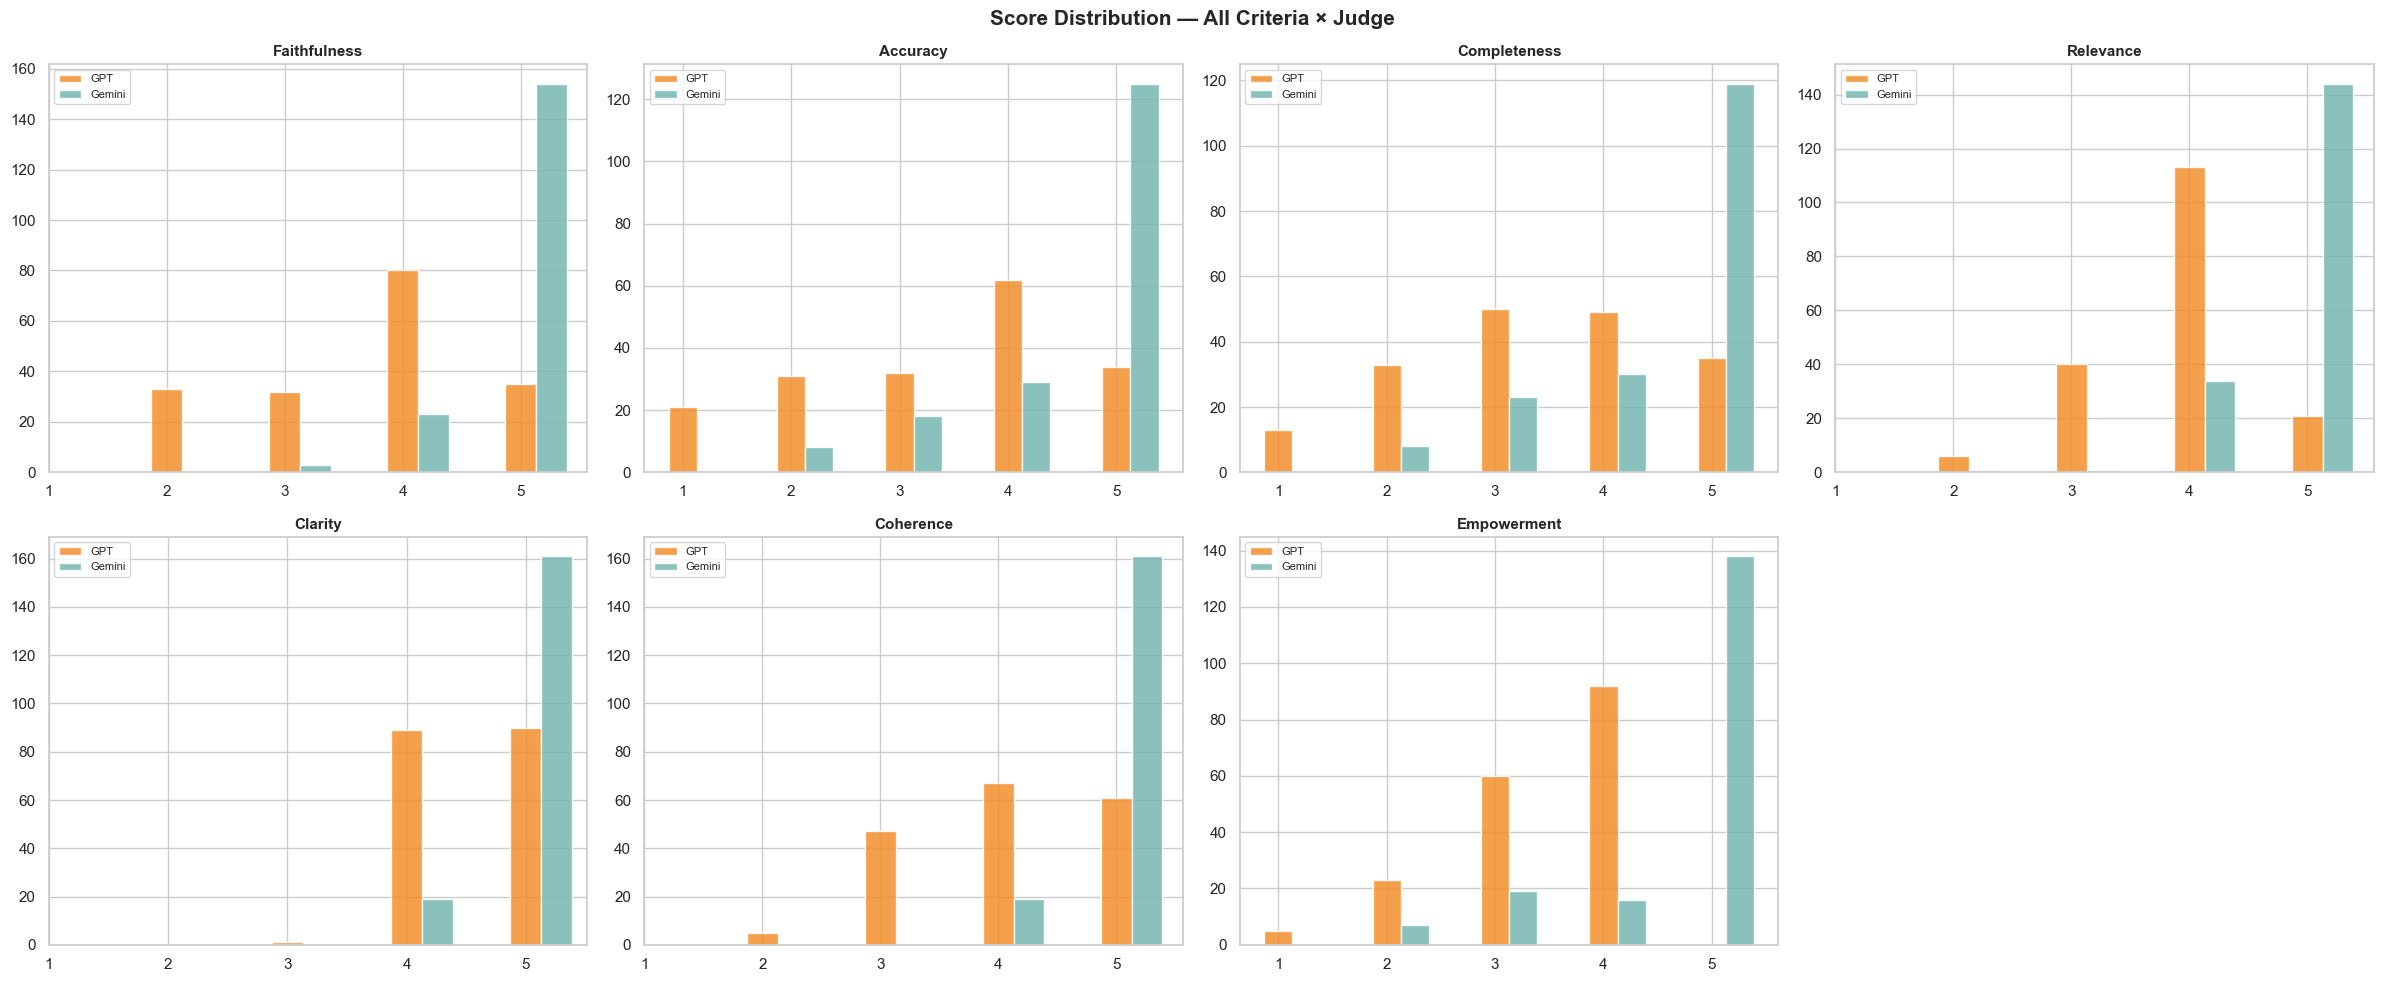

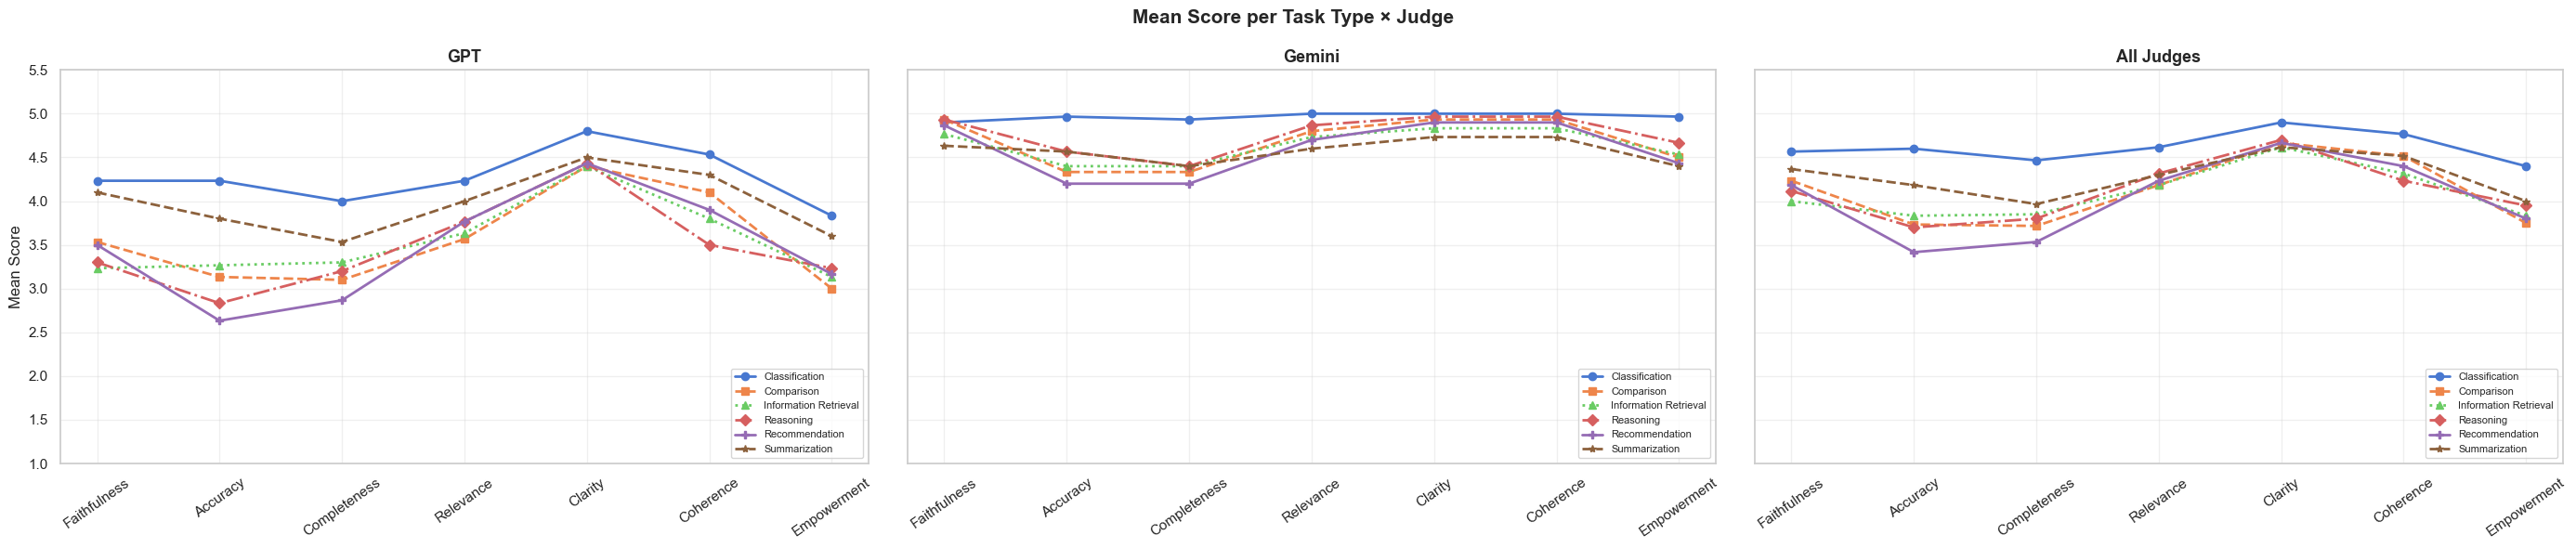


Mean Score per Task Type (all judges aggregated):
                       Faithfulness  Accuracy  Completeness  Relevance  Clarity  Coherence  Empowerment
Category                                                                                               
Classification                 4.57      4.60          4.47       4.62     4.90       4.77         4.40
Comparison                     4.23      3.73          3.72       4.18     4.67       4.52         3.75
Information Retrieval          4.00      3.83          3.85       4.18     4.62       4.32         3.83
Reasoning                      4.12      3.70          3.80       4.32     4.70       4.23         3.95
Recommendation                 4.18      3.42          3.53       4.23     4.67       4.40         3.80
Summarization                  4.37      4.18          3.97       4.30     4.62       4.52         4.00


In [7]:
# ── 3.6 Results: heatmap + distribution + per-category ───────────────────────

valid_res = all_res.dropna(subset=SC)
palette   = {"openai": "#f28e2b", "gemini": "#76b7b2"}

# Heatmap — mean score per criterion × judge
pv = valid_res.groupby("judge")[SC].mean()
pv.columns = LABELS
pv.index   = pv.index.map(JUDGE_LABELS)

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(pv, annot=True, fmt=".2f", cmap="RdYlGn", vmin=1, vmax=5, linewidths=.5, ax=ax)
ax.set_title("Mean Score per Criterion × Judge", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(f"{config.output_dir}heatmap_mean.png", dpi=150)
plt.show()

# Distribution — all criteria
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
w = 0.26
offsets = {"openai": 0, "gemini": w}
for i, (col, lab) in enumerate(zip(SC, LABELS)):
    ax = axes[i // 4, i % 4]
    for jk, jl in JUDGE_LABELS.items():
        v = valid_res[valid_res["judge"] == jk][col].value_counts().sort_index()
        ax.bar(v.index + offsets[jk], v.values, width=w, label=jl, alpha=0.85, color=palette[jk])
    ax.set_title(lab, fontweight="bold", fontsize=11)
    ax.set_xticks(range(1, 6))
    ax.legend(fontsize=8)
axes[1, 3].set_visible(False)
plt.suptitle("Score Distribution — All Criteria × Judge", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{config.output_dir}distribution.png", dpi=150)
plt.show()

# Per task type
task_types = sorted(valid_res["Category"].unique())
judges_ext = list(JUDGE_LABELS.items()) + [("all", "All Judges")]
fig, axes = plt.subplots(1, 3, figsize=(28, 6), sharey=True)
ls_map = dict(zip(task_types, ["o-","s--","^:","D-.","P-","*--"]))
for ax_i, (jk, jl) in enumerate(judges_ext):
    ax  = axes[ax_i]
    sub = valid_res if jk == "all" else valid_res[valid_res["judge"] == jk]
    for tt in task_types:
        tt_sub = sub[sub["Category"] == tt]
        if len(tt_sub) == 0: continue
        means = [tt_sub[col].mean() for col in SC]
        ax.plot(LABELS, means, ls_map.get(tt, "o-"), label=tt, linewidth=2, markersize=6)
    ax.set_title(jl, fontweight="bold", fontsize=13)
    ax.set_ylim(1, 5.5); ax.tick_params(axis="x", rotation=35); ax.grid(alpha=.3)
    if ax_i == 0: ax.set_ylabel("Mean Score")
    ax.legend(fontsize=8, loc="lower right")
plt.suptitle("Mean Score per Task Type × Judge", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{config.output_dir}by_tasktype_line.png", dpi=150)
plt.show()
print("\nMean Score per Task Type (all judges aggregated):")
print(valid_res.groupby("Category")[SC].mean().rename(columns=dict(zip(SC, LABELS))).round(2).to_string())


Inter-Judge Agreement (Spearman ρ)

  GPT vs Gemini  (n=91 paired observations)
                  rs         p  pct_exact  pct_within1
Faithfulness  0.0602  0.421733       19.4         68.3
Accuracy      0.6740  0.000000       24.4         64.4
Completeness  0.7287  0.000000       26.1         65.6
Relevance     0.2248  0.002410       18.3         82.2
Clarity      -0.0557  0.457718       48.3         99.4
Coherence    -0.0076  0.919834       33.3         74.4
Empowerment   0.4886  0.000000        8.9         66.1
  → Mean ρ: 0.3019 | Exact agreement: 25.5% | Within ±1: 74.3%

Spearman Matrix:
           GPT  Gemini
GPT     1.0000  0.3019
Gemini  0.3019  1.0000


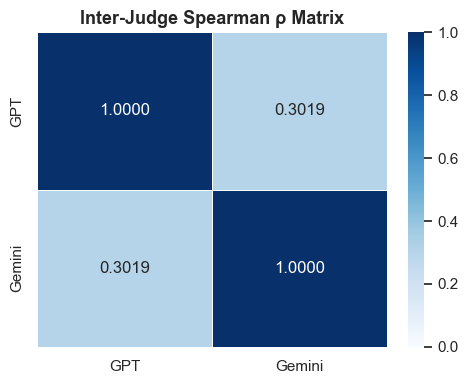

In [8]:
# ── 3.7 Inter-judge agreement (Spearman ρ) ───────────────────────────────────

def norm_tid(x):
    try:
        f = float(x)
        return str(int(f)) if f == int(f) else str(f)
    except:
        return str(x)


def spearman_pair(df_all, j1, j2):
    def idx_set(j):
        sub = df_all[df_all["judge"] == j].copy()
        sub["key"] = sub["Task_ID"].apply(norm_tid).astype(str) + "_" + sub["Variant"].astype(str)
        return sub.set_index("key")
    a, b   = idx_set(j1), idx_set(j2)
    common = a.index.intersection(b.index)
    result = {}
    for col, lab in zip(SC, LABELS):
        if len(common) < 3:
            result[lab] = {"rs": float("nan"), "p": float("nan"),
                           "pct_exact": float("nan"), "pct_within1": float("nan")}
        else:
            x, y        = a.loc[common, col], b.loc[common, col]
            rs, pv      = stats.spearmanr(x, y)
            pct_exact   = (x == y).mean() * 100
            pct_within1 = (abs(x - y) <= 1).mean() * 100
            result[lab] = {"rs": round(rs, 4), "p": round(pv, 6),
                           "pct_exact": round(pct_exact, 1), "pct_within1": round(pct_within1, 1)}
    return pd.DataFrame(result).T, len(common)


pairs = [("openai", "gemini", "GPT vs Gemini")]

rs_matrix = pd.DataFrame(np.eye(2), index=["GPT", "Gemini"], columns=["GPT", "Gemini"])
summary_agree = []

print("Inter-Judge Agreement (Spearman ρ)\n" + "=" * 65)
for j1, j2, label in pairs:
    agdf, n  = spearman_pair(valid_res, j1, j2)
    mean_rs  = agdf["rs"].dropna().mean()
    mean_ex  = agdf["pct_exact"].dropna().mean()
    mean_w1  = agdf["pct_within1"].dropna().mean()
    print(f"\n  {label}  (n={n} paired observations)")
    print(agdf[["rs","p","pct_exact","pct_within1"]].to_string())
    print(f"  → Mean ρ: {mean_rs:.4f} | Exact agreement: {mean_ex:.1f}% | Within ±1: {mean_w1:.1f}%")
    jl1, jl2 = JUDGE_LABELS[j1], JUDGE_LABELS[j2]
    rs_matrix.loc[jl1, jl2] = round(mean_rs, 4)
    rs_matrix.loc[jl2, jl1] = round(mean_rs, 4)
    summary_agree.append({"Pair": label, "Mean ρ": round(mean_rs,4),
                           "Exact (%)": round(mean_ex,1), "Within ±1 (%)": round(mean_w1,1)})

print("\nSpearman Matrix:")
print(rs_matrix.to_string())

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(rs_matrix.astype(float), annot=True, fmt=".4f", cmap="Blues",
            vmin=0, vmax=1, linewidths=.5, ax=ax)
ax.set_title("Inter-Judge Spearman ρ Matrix", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(f"{config.output_dir}spearman_matrix.png", dpi=150)
plt.show()


  REPORT — LLM-as-a-Judge  GraphRAG LOTO

  GPT  (180 valid evaluations)
  --------------------------------------------------
    Faithfulness               ███░░  3.65 ± 0.99  (≥4: 64%)
    Accuracy                   ███░░  3.32 ± 1.28  (≥4: 53%)
    Completeness               ███░░  3.33 ± 1.19  (≥4: 47%)
    Relevance                  ███░░  3.83 ± 0.67  (≥4: 74%)
    Clarity                    ████░  4.49 ± 0.51  (≥4: 99%)
    Coherence                  ████░  4.02 ± 0.85  (≥4: 71%)
    Empowerment                ███░░  3.33 ± 0.80  (≥4: 51%)
    Ctx Confidence             4.14

  Gemini  (180 valid evaluations)
  --------------------------------------------------
    Faithfulness               ████░  4.84 ± 0.41  (≥4: 98%)
    Accuracy                   ████░  4.51 ± 0.85  (≥4: 86%)
    Completeness               ████░  4.44 ± 0.88  (≥4: 83%)
    Relevance                  ████░  4.78 ± 0.46  (≥4: 99%)
    Clarity                    ████░  4.89 ± 0.31  (≥4: 100%)
    Coherence    

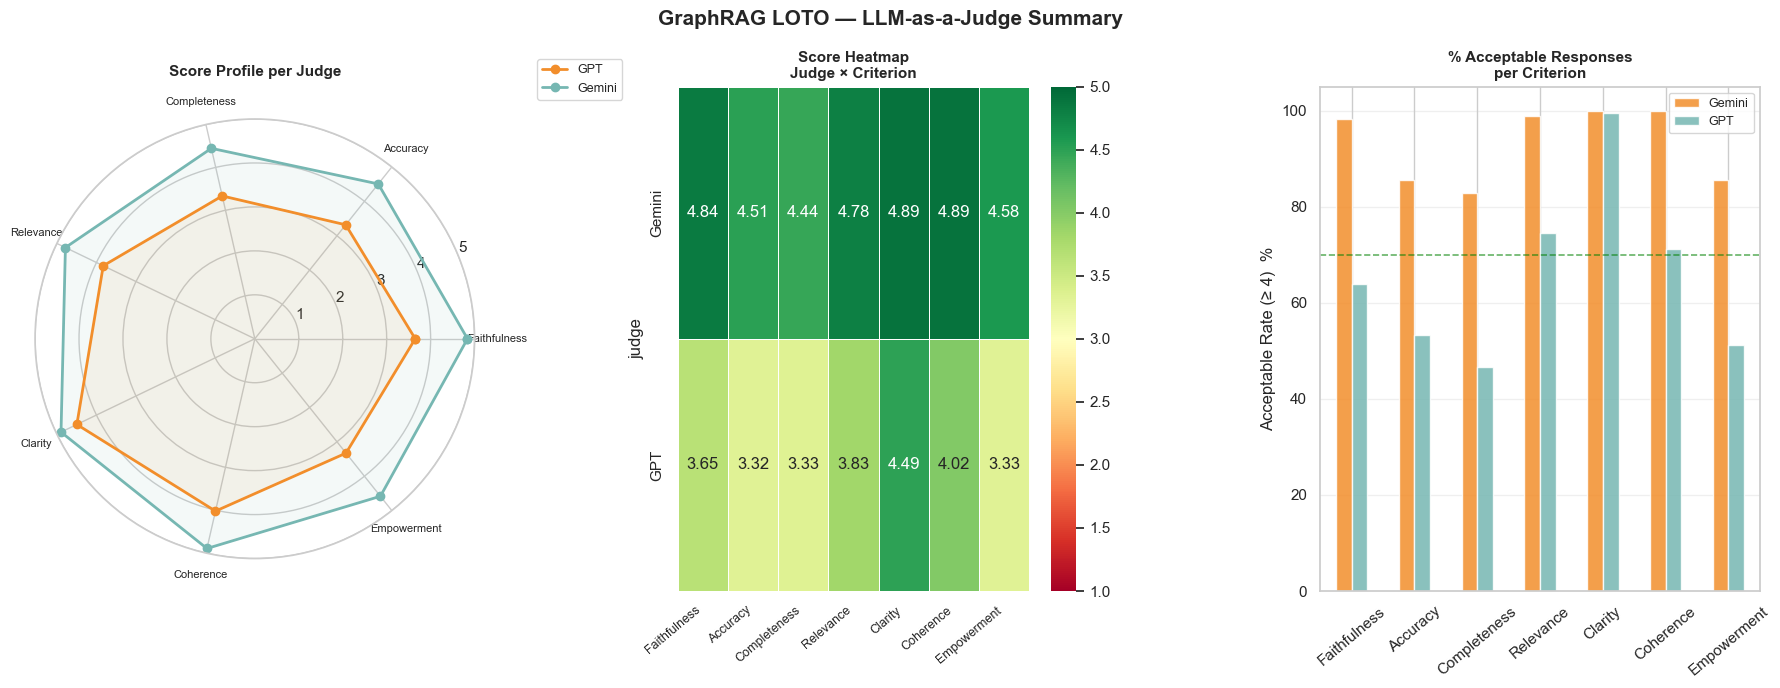

In [9]:
# ── 3.8 Summary report ───────────────────────────────────────────────────────

print("=" * 70)
print("  REPORT — LLM-as-a-Judge  GraphRAG LOTO")
print("=" * 70)

for jlabel, jkey in [("GPT","openai"),("Gemini","gemini")]:
    sub = valid_res[valid_res["judge"] == jkey]
    if not len(sub): continue
    print(f"\n  {jlabel}  ({len(sub)} valid evaluations)")
    print(f"  {'-'*50}")
    for col, lab in zip(SC, LABELS):
        m, s = sub[col].mean(), sub[col].std()
        bar  = "█" * int(m) + "░" * (5 - int(m))
        pct  = (sub[col] >= 4).mean() * 100
        print(f"    {lab:25s}  {bar}  {m:.2f} ± {s:.2f}  (≥4: {pct:.0f}%)")
    print(f"    {'Ctx Confidence':25s}  {sub['ctx_conf'].mean():.2f}")

print("\n\n  RESULTS BY TASK CATEGORY  (all judges aggregated)")
print(f"  {'-'*60}")
cm = valid_res.groupby("Category")[SC].mean()
cm.columns = LABELS
print(cm.round(2).to_string())

# Radar + summary chart
fig = plt.figure(figsize=(18, 7))
fig.suptitle("GraphRAG LOTO — LLM-as-a-Judge Summary", fontsize=15, fontweight="bold")

# Radar
ax_r = fig.add_subplot(1, 3, 1, polar=True)
angles = np.linspace(0, 2*np.pi, len(LABELS), endpoint=False).tolist()
angles += angles[:1]
for jkey, jlabel in [("openai","GPT"),("gemini","Gemini")]:
    sub    = valid_res[valid_res["judge"] == jkey]
    values = [sub[c].mean() for c in SC] if len(sub) else [0]*len(SC)
    values += values[:1]
    ax_r.plot(angles, values, "o-", linewidth=2, label=jlabel, color=palette[jkey])
    ax_r.fill(angles, values, alpha=0.08, color=palette[jkey])
ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(LABELS, fontsize=8)
ax_r.set_ylim(0, 5); ax_r.set_yticks([1,2,3,4,5])
ax_r.set_title("Score Profile per Judge", fontweight="bold", fontsize=11, pad=15)
ax_r.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)

# Heatmap
ax_h = fig.add_subplot(1, 3, 2)
pv_all = valid_res.groupby("judge")[SC].mean()
pv_all.columns = LABELS; pv_all.index = pv_all.index.map(JUDGE_LABELS)
sns.heatmap(pv_all, annot=True, fmt=".2f", cmap="RdYlGn", vmin=1, vmax=5, linewidths=.5, ax=ax_h)
ax_h.set_title("Score Heatmap\nJudge × Criterion", fontweight="bold", fontsize=11)
ax_h.set_xticklabels(LABELS, rotation=40, ha="right", fontsize=9)

# Acceptable rate (≥4)
ax_a = fig.add_subplot(1, 3, 3)
sar_means = valid_res.groupby("judge")[[f"sar_{f}" for f in SCORE_FIELDS]].mean() * 100
sar_means.columns = LABELS; sar_means.index = sar_means.index.map(JUDGE_LABELS)
sar_means.T.plot(kind="bar", ax=ax_a, color=[palette["openai"], palette["gemini"]], alpha=0.85)
ax_a.set_ylabel("Acceptable Rate (≥ 4)  %"); ax_a.set_ylim(0, 105)
ax_a.set_title("% Acceptable Responses\nper Criterion", fontweight="bold", fontsize=11)
ax_a.tick_params(axis="x", rotation=40); ax_a.legend(fontsize=9)
ax_a.axhline(70, color="green", lw=1.2, ls="--", alpha=0.6, label="70% threshold")
ax_a.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config.output_dir}summary_report.png", dpi=150)
plt.show()


---
## 💰 Section 4 — Evaluation Cost

Actual token usage and USD cost for the LLM-as-a-Judge evaluation run, computed from real usage metadata reported by each API. Prices are read from the `PRICING` dict defined in Cell 1 — update if rates change.

  EVALUATION COST — LLM-as-a-Judge
          n  tok_in  tok_out  avg_s     usd
judge                                      
Gemini  180  865605    86350    3.1  0.0908
GPT     180  807000    93994    8.4  2.9574

Total estimated cost: $3.0482
Avg cost per query  : $0.00847



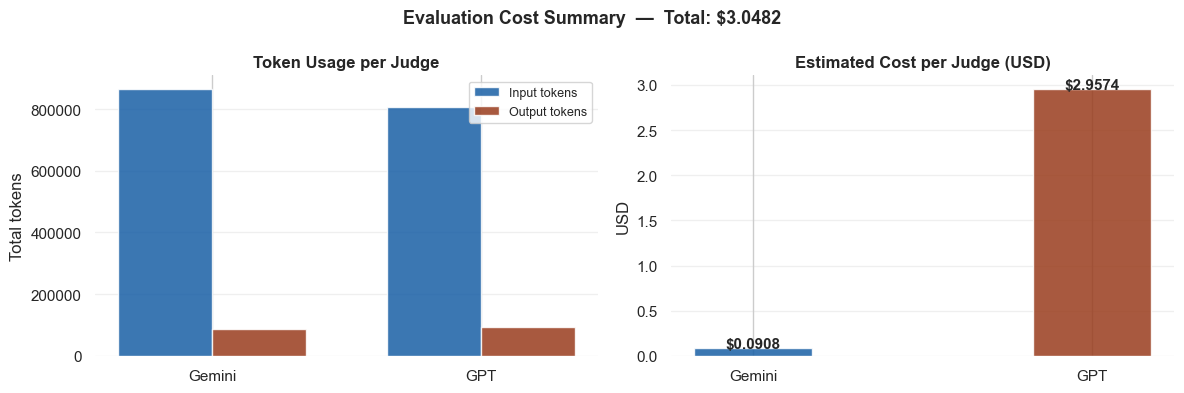

Cost chart saved: Evaluationresults/eval_cost.png ✓

Note: Prices are read from the PRICING dict in Cell 1.
Update them at https://openai.com/pricing and https://ai.google.dev/pricing


In [10]:
# ── 4.1 Cost computation from actual token usage ─────────────────────────────

u = all_res.groupby("judge").agg(
    n       = ("Task_ID", "count"),
    tok_in  = ("tok_in",  "sum"),
    tok_out = ("tok_out", "sum"),
    avg_s   = ("time_s",  "mean"),
).round(1)

for j in u.index:
    p = PRICING.get(j, {"i": 0, "o": 0})
    u.loc[j, "usd"] = round(
        u.loc[j, "tok_in"]  / 1e6 * p["i"] +
        u.loc[j, "tok_out"] / 1e6 * p["o"], 4
    )

u.index = u.index.map({"openai": "GPT", "gemini": "Gemini"})
print("=" * 55)
print("  EVALUATION COST — LLM-as-a-Judge")
print("=" * 55)
print(u[["n", "tok_in", "tok_out", "avg_s", "usd"]].to_string())
print(f"\nTotal estimated cost: ${u['usd'].sum():.4f}")
print(f"Avg cost per query  : ${u['usd'].sum() / u['n'].sum():.5f}")
print()

# Cost breakdown chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="white")

# Token usage
ax = axes[0]
bar_w = 0.35
x_pos = np.arange(len(u))
ax.bar(x_pos - bar_w/2, u["tok_in"],  bar_w, label="Input tokens",  color="#185FA5", alpha=0.85)
ax.bar(x_pos + bar_w/2, u["tok_out"], bar_w, label="Output tokens", color="#993C1D", alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(u.index)
ax.set_ylabel("Total tokens"); ax.set_title("Token Usage per Judge", fontweight="bold")
ax.legend(fontsize=9); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
for spine in ax.spines.values(): spine.set_visible(False)

# USD cost
ax2 = axes[1]
colors = ["#185FA5", "#993C1D", "#3B6D11"]
bars = ax2.bar(u.index, u["usd"], color=colors[:len(u)], alpha=0.85, width=0.35)
for bar, val in zip(bars, u["usd"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f"${val:.4f}", ha="center", fontsize=11, fontweight="bold")
ax2.set_ylabel("USD"); ax2.set_title("Estimated Cost per Judge (USD)", fontweight="bold")
ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)
for spine in ax2.spines.values(): spine.set_visible(False)

plt.suptitle(f"Evaluation Cost Summary  —  Total: ${u['usd'].sum():.4f}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{config.output_dir}eval_cost.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Cost chart saved: {config.output_dir}eval_cost.png ✓")
print()
print("Note: Prices are read from the PRICING dict in Cell 1.")
print("Update them at https://openai.com/pricing and https://ai.google.dev/pricing")
